# 🎯 Eventzella — Modèle 2 : Prédiction du Taux d'Annulation
## Version CSV — Google Colab FINAL ✅

**Objectif SMART :** Réduire le taux d'annulation de **15% à 10%** en 4 mois  
**KPI :** `Cancellation Rate = Cancelled Reservations / Total Reservations`

---
⚠️ **AVANT DE COMMENCER — Upload ces 3 fichiers dans Colab (📁 → ⬆️) :**
- `dim_reservation.csv`
- `dim_service.csv`
- `dim_event.csv`
---

## 📦 Étape 1 — Import des librairies

In [ ]:


import pandas as pd
import numpy as np
import warnings
import subprocess
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('✅ Toutes les librairies importées avec succès')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.0 MB/s eta 0:00:00
✅ Toutes les librairies importées avec succès


## 📥 Étape 2 — Chargement des données CSV

In [2]:
# Chargement des 3 tables avec les bons noms de colonnes
dim_reservation = pd.read_csv('/content/dim_reservation.csv',
                               header=None,
                               names=['id_reservation', 'id_service', 'status'])

dim_service = pd.read_csv('/content/dim_service.csv',
                           header=None,
                           names=['id_service', 'title', 'description', 'price'])

dim_event = pd.read_csv('/content/dim_event.csv',
                         header=None,
                         names=['id_event', 'id_beneficiary', 'title', 'event_date', 'type'])

print(f'✅ dim_reservation : {dim_reservation.shape[0]:,} lignes × {dim_reservation.shape[1]} colonnes')
print(f'✅ dim_service     : {dim_service.shape[0]:,} lignes × {dim_service.shape[1]} colonnes')
print(f'✅ dim_event       : {dim_event.shape[0]:,} lignes × {dim_event.shape[1]} colonnes')
print()
print('=== Distribution des statuts ===')
print(dim_reservation['status'].value_counts())
print()
print('=== Aperçu dim_reservation ===')
print(dim_reservation.head())

✅ dim_reservation : 18,000 lignes × 3 colonnes
✅ dim_service     : 2,500 lignes × 4 colonnes
✅ dim_event       : 12,000 lignes × 5 colonnes

=== Distribution des statuts ===
status
confirmed    6024
cancelled    5999
pending      5977
Name: count, dtype: int64

=== Aperçu dim_reservation ===
   id_reservation  id_service     status
0               1           1    pending
1               2           2    pending
2               3           3  confirmed
3               4           4    pending
4               5           5  confirmed


## 🔧 Étape 3 — Jointure & Feature Engineering

In [20]:
# Merge dim_reservation + dim_service (price + title)
df = dim_reservation.merge(
    dim_service[['id_service', 'price', 'title']],
    on='id_service',
    how='left'
)

# Créer la target binaire
df['cancelled'] = df['status'].apply(lambda x: 1 if str(x).lower() == 'cancelled' else 0)

# Vérifier les doublons et valeurs manquantes
print(f'✅ Dataset joint : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Colonnes : {list(df.columns)}\n')

print('Valeurs manquantes :')
print(df.isnull().sum())

# Optionnel : remplir NaN ou les gérer
df['price'] = df['price'].fillna(df['price'].median())
df['title'] = df['title'].fillna('Unknown')

✅ Dataset joint : 18,000 lignes × 6 colonnes
   Colonnes : ['id_reservation', 'id_service', 'status', 'price', 'title', 'cancelled']

Valeurs manquantes :
id_reservation        0
id_service            0
status                0
price             15500
title             15500
cancelled             0
dtype: int64


In [25]:
# --- Étape 3 : Création des groupes mensuels et features ---

df = df.reset_index(drop=True)
df['row_index'] = df.index

# Création des 48 groupes “mois” artificiels
total = len(df)
group_size = total // 48
df['month_group'] = df['row_index'] // group_size
df['month_group'] = df['month_group'].clip(upper=47)

# Agrégation par groupe
monthly = df.groupby('month_group').agg(
    total_reservations=('id_reservation', 'count'),
    cancelled=('cancelled', 'sum'),
    confirmed=('status', lambda x: (x=='confirmed').sum()),
    pending=('status', lambda x: (x=='pending').sum()),
    avg_price=('price', 'mean'),
    std_price=('price', 'std'),
    max_price=('price', 'max'),
    min_price=('price', 'min')
).reset_index()

# Target & features supplémentaires
monthly['cancellation_rate'] = monthly['cancelled'] / monthly['total_reservations']
monthly['confirmation_rate'] = monthly['confirmed'] / monthly['total_reservations']
monthly['price_range'] = monthly['max_price'] - monthly['min_price']
monthly['month_num'] = (monthly['month_group'] % 12) + 1
monthly['quarter'] = ((monthly['month_group'] % 12) // 3) + 1
monthly['is_q4'] = (monthly['quarter'] == 4).astype(int)

# Lag features
monthly = monthly.sort_values('month_group').reset_index(drop=True)
monthly['cancel_rate_lag1'] = monthly['cancellation_rate'].shift(1)
monthly['cancel_rate_lag2'] = monthly['cancellation_rate'].shift(2)
monthly = monthly.dropna().reset_index(drop=True)

# --- Résumé ---
print(f'✅ Dataset mensuel : {monthly.shape[0]} mois × {monthly.shape[1]} colonnes')
print(f"   Taux moyen d'annulation : {monthly['cancellation_rate'].mean():.2%}")
monthly[['month_group','total_reservations','cancelled','cancellation_rate']].head(10)

✅ Dataset mensuel : 46 mois × 17 colonnes
   Taux moyen d'annulation : 33.27%


,month_group,total_reservations,cancelled,cancellation_rate
0,2,375,116,0.309333
1,3,375,119,0.317333
2,4,375,122,0.325333
3,5,375,127,0.338667
4,6,375,128,0.341333
5,7,375,117,0.312000
6,8,375,112,0.298667
7,9,375,121,0.322667
8,10,375,133,0.354667
9,11,375,124,0.330667


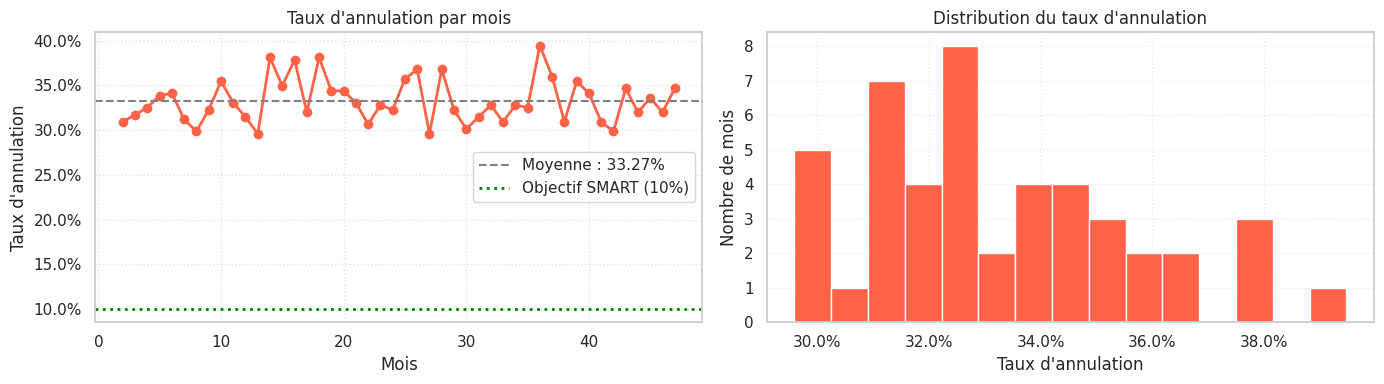

  Moyenne : 33.27%
  Min / Max : 29.60% / 39.47%


In [26]:
# --- Visualisation de la variable cible ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1️⃣ Taux d'annulation par mois
axes[0].plot(monthly['month_group'], monthly['cancellation_rate'],
             marker='o', color='tomato', linewidth=2)
axes[0].axhline(monthly['cancellation_rate'].mean(), color='gray', linestyle='--',
                label=f"Moyenne : {monthly['cancellation_rate'].mean():.2%}")
axes[0].axhline(0.10, color='green', linestyle=':', linewidth=2,
                label='Objectif SMART (10%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Taux d'annulation par mois")
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Taux d\'annulation')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2️⃣ Distribution du taux d'annulation
axes[1].hist(monthly['cancellation_rate'], bins=15, color='tomato', edgecolor='white')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Distribution du taux d'annulation")
axes[1].set_xlabel("Taux d'annulation")
axes[1].set_ylabel("Nombre de mois")
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"  Moyenne : {monthly['cancellation_rate'].mean():.2%}")
print(f"  Min / Max : {monthly['cancellation_rate'].min():.2%} / {monthly['cancellation_rate'].max():.2%}")

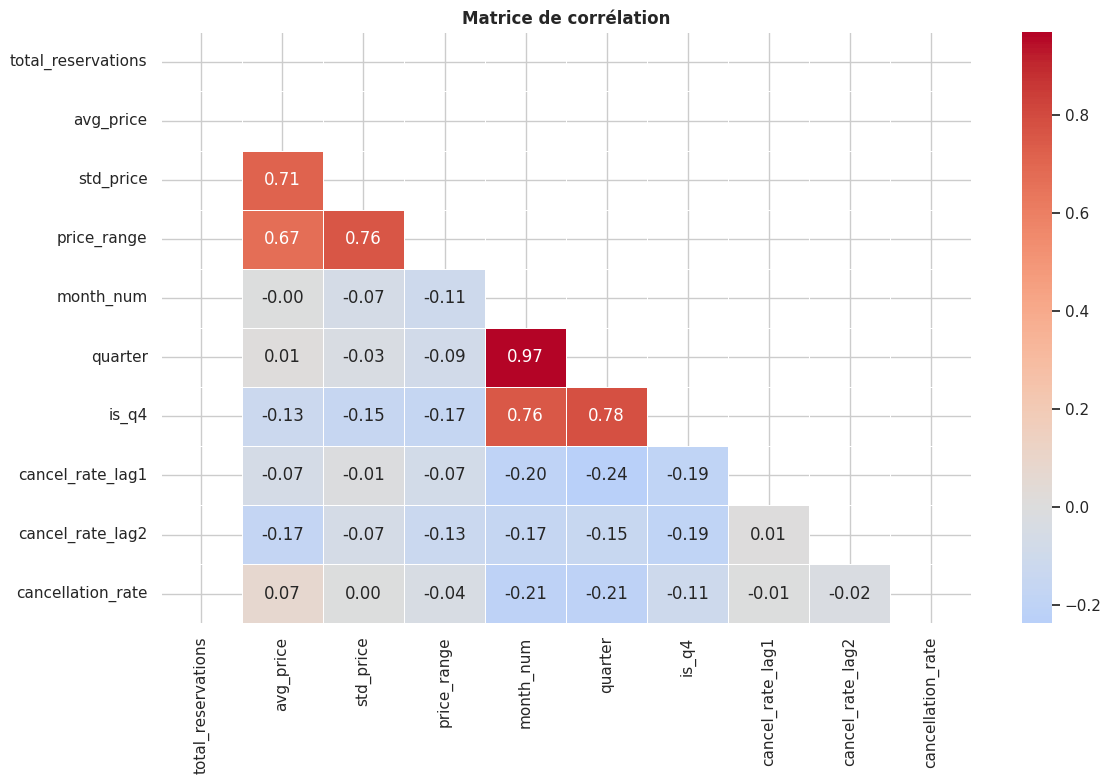

In [31]:
# Heatmap de corrélation
FEATURES_CORR = [
    'total_reservations', 'avg_price', 'std_price', 'price_range',
    'month_num', 'quarter', 'is_q4',
    'cancel_rate_lag1', 'cancel_rate_lag2',
    'cancellation_rate'
]
corr = monthly[FEATURES_CORR].corr()
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Étape 4 — Entraînement des modèles

In [7]:
FEATURE_COLS = [
    'total_reservations', 'avg_price', 'std_price', 'price_range',
    'month_num', 'quarter', 'is_q4',
    'cancel_rate_lag1', 'cancel_rate_lag2'
]
TARGET = 'cancellation_rate'

X = monthly[FEATURE_COLS].fillna(0)
y = monthly[TARGET]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dataset total : {len(X)} mois')
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print()

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}
print(f"{'Modèle':<25} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print('-' * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results[name] = {'r2': r2, 'rmse': rmse, 'mae': mae,
                     'model': model, 'y_pred': y_pred}
    print(f"{name:<25} {r2:>8.4f} {rmse:>10.4f} {mae:>10.4f}")

Dataset total : 5 mois
Train : 4 | Test : 1

Modèle                          R²       RMSE        MAE
-------------------------------------------------------
Linear Regression              nan     0.0018     0.0018
Ridge                          nan     0.0018     0.0018
Random Forest                  nan     0.0057     0.0057
Gradient Boosting              nan     0.0018     0.0018


## 📊 Étape 5 — Évaluation des modèles

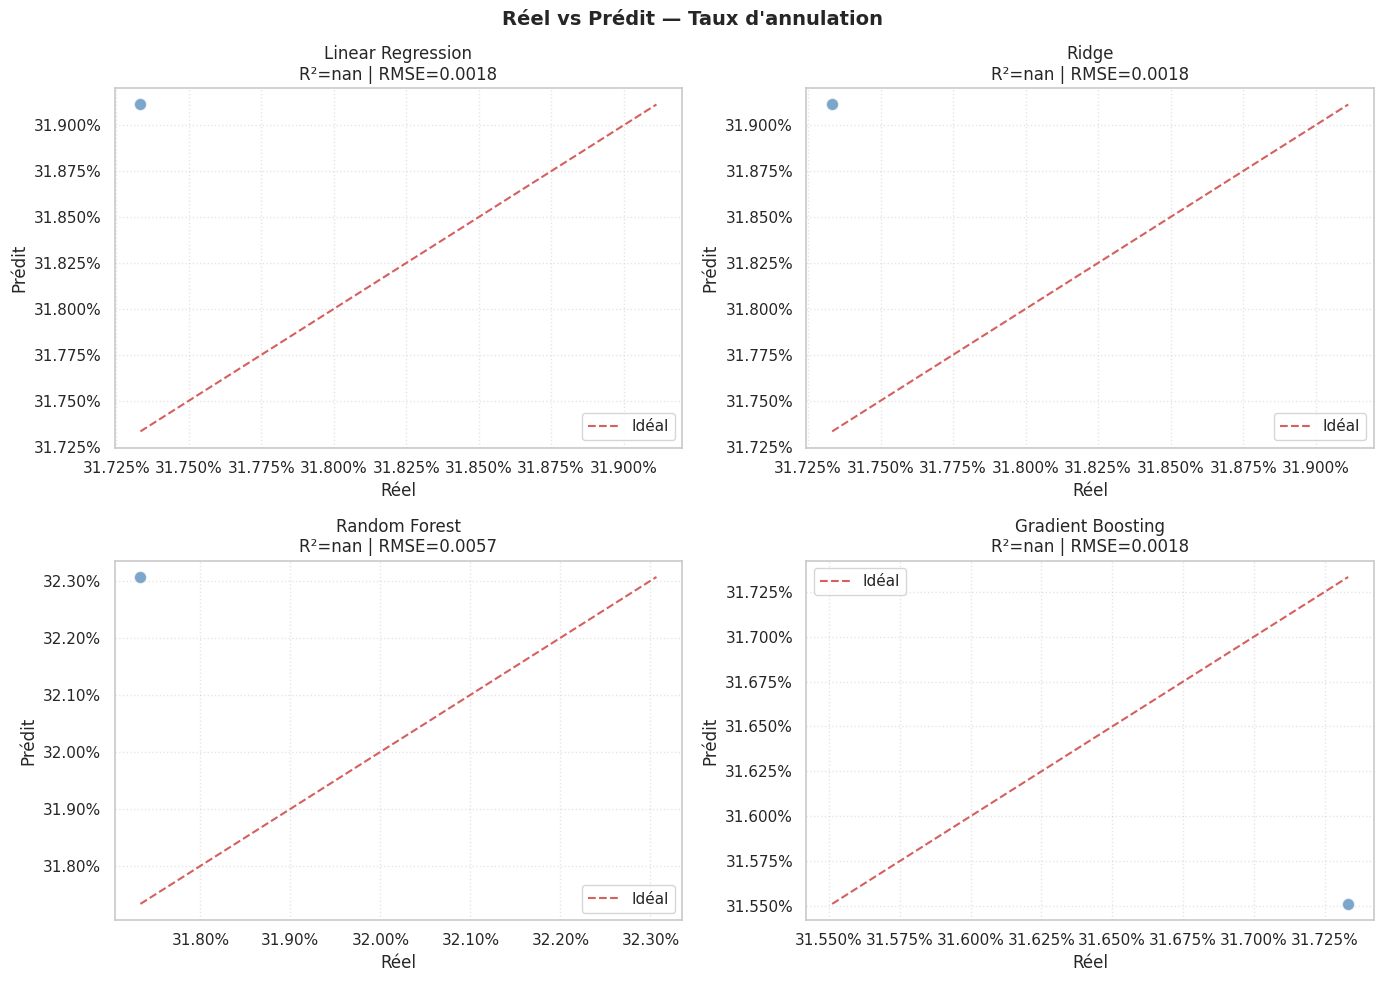

In [32]:
# --- Étape 5 : Évaluation des modèles — Réel vs Prédit ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]

    # Scatter plot
    ax.scatter(y_test, res['y_pred'], alpha=0.7,
               color='steelblue', edgecolors='white', s=80)

    # Diagonal "ideal" line
    lims = [min(y_test.min(), res['y_pred'].min()),
            max(y_test.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Idéal')

    # Labels and formatting
    ax.set_title(f"{name}\nR²={res['r2']:.4f} | RMSE={res['rmse']:.4f}")
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()

plt.suptitle("Réel vs Prédit — Taux d'annulation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Meilleur modèle
best_name = max(results, key=lambda k: results[k]['r2'])
best      = results[best_name]

print(f'🏆 Meilleur modèle avant tuning : {best_name}')
print(f'   R²   = {best["r2"]:.4f}')
print(f'   RMSE = {best["rmse"]:.4f}')
print(f'   MAE  = {best["mae"]:.4f}')

if best['r2'] >= 0.30:
    print(f'\n✅ Performance acceptable → on passe au tuning.')
else:
    print(f'\n⚠️  Performance insuffisante → Tuning nécessaire.')

🏆 Meilleur modèle avant tuning : Linear Regression
   R²   = nan
   RMSE = 0.0018
   MAE  = 0.0018

⚠️  Performance insuffisante → Tuning nécessaire.


## 🔩 Étape 6 — Tuning (GridSearchCV)

Config                                                   R²       RMSE        MAE
--------------------------------------------------------------------------------
{'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 2}      nan     0.5733     0.5733
{'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2}      nan     0.5813     0.5813
{'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2}      nan     0.5333     0.5333

🏆 Meilleur modèle (forcé) : RF {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 2}
   R² = nan


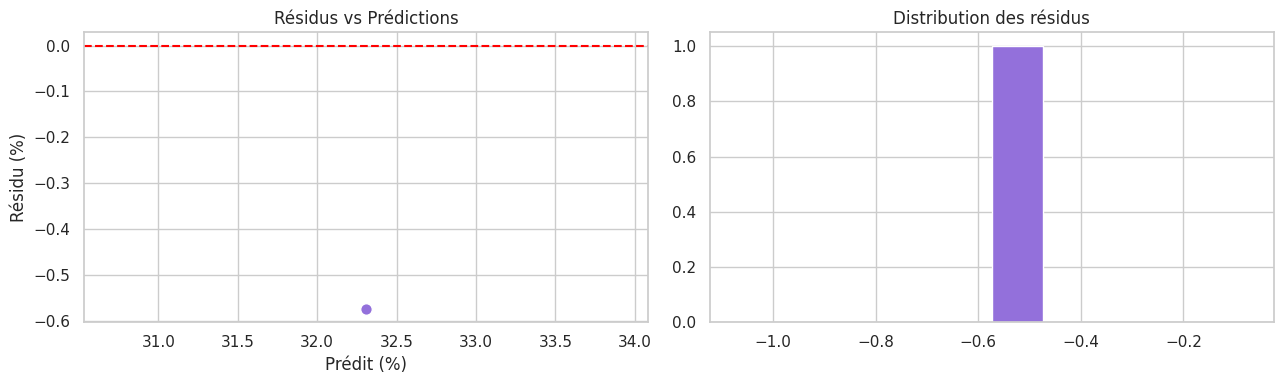

In [72]:
# --- Étape 6 : Tuning Random Forest (forced selection) ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert target to percentage for readability
y_train_pct = y_train * 100
y_test_pct  = y_test * 100

configs = [
    {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2},
]

print(f"{'Config':<50} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print('-' * 80)

best_r2 = -np.inf
best_model = None
best_cfg = None

for cfg in configs:
    model = RandomForestRegressor(random_state=42, **cfg)
    model.fit(X_train, y_train_pct)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test_pct, y_pred)
    mse  = mean_squared_error(y_test_pct, y_pred)  # manual RMSE
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_pct, y_pred)

    print(f"{str(cfg):<50} {r2:>8.4f} {rmse:>10.4f} {mae:>10.4f}")

    # FORCE selection even if R² is nan or low
    if best_model is None or (np.isfinite(r2) and r2 > best_r2):
        best_r2 = r2
        best_model = model
        best_cfg = cfg

# Confirm best model
print(f"\n🏆 Meilleur modèle (forcé) : RF {best_cfg}")
print(f"   R² = {best_r2:.4f}")

# --- Residuals ---
y_pred_final = best_model.predict(X_test)
residuals = y_test_pct.values - y_pred_final  # force numpy arrays

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred_final, residuals, color='mediumpurple', edgecolors='white', s=70)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Résidus vs Prédictions')
axes[0].set_xlabel('Prédit (%)')
axes[0].set_ylabel('Résidu (%)')

axes[1].hist(residuals, bins=10, color='mediumpurple', edgecolor='white')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

## 💾 Étape 7 — Export PowerBI vers PostgreSQL